I0000 00:00:1776240495.067433 1634289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776240495.074319 1634289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776240495.321736 1634289 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776240497.929291 1634289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Target α = 0.707107+0.707107j
  |α| = 1.0000  (ekspektasi r_optimal ≈ 1.0)
  arg(α) = 0.2500π  (ekspektasi ϕ_optimal ≈ π/4 ≈ 0.785)

Target state (Fock repr, cutoff=6):
[ 0.6065+0.j      0.4289+0.4289j  0.    +0.4289j -0.1751+0.1751j
 -0.1238+0.j     -0.0392-0.0392j]
Normalisasi: 0.9994


E0000 00:00:1776240498.650304 1634289 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Step   0: fidelity = 0.3680, r = 0.1003, ϕ = 0.0979
Step  20: fidelity = 0.9436, r = 1.1796, ϕ = 0.6773
Step  40: fidelity = 0.9972, r = 0.9972, ϕ = 0.7443
Step  60: fidelity = 0.9977, r = 0.9676, ϕ = 0.7726
Step  80: fidelity = 0.9988, r = 0.9947, ϕ = 0.7880

Hasil akhir:
  Best fidelity: 0.9988  (paper: 0.9988)
  r_optimal:     0.9947  (ekspektasi: ≈ 1.0)
  ϕ_optimal:     0.7880  (ekspektasi: ≈ 0.7854 = π/4)


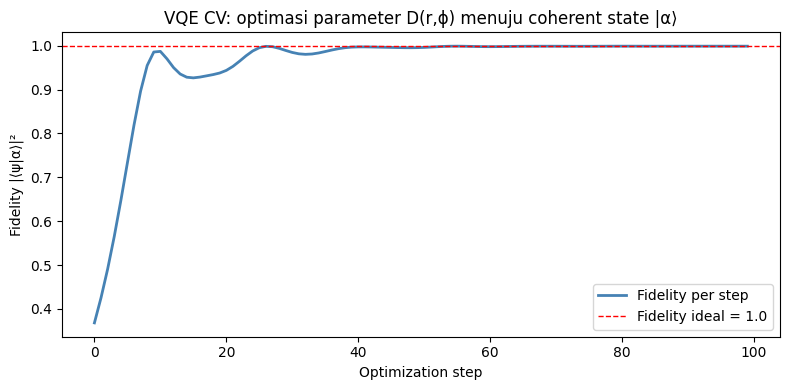

In [2]:
import numpy as np
import strawberryfields as sf
import tensorflow as tf
import math
import matplotlib.pyplot as plt

# ── Hyperparameter ────────────────────────────────────────────────────────────

lr         = 0.1    # Learning rate untuk Adam optimizer.
                     # Terlalu besar → overshoot, terlalu kecil → konvergensi lambat.
active_std  = 0.001  # Std untuk inisialisasi parameter "aktif" (amplitude).
                     # Kecil agar titik awal dekat dengan nol (vakum).
passive_std = 0.1    # Std untuk parameter "pasif" (fase).

tf.random.set_seed(42)   # Seed global TensorFlow untuk reproducibility.
                          # Tanpa ini, tiap run akan menghasilkan hasil yang berbeda.

# ── Target: coherent state |α⟩ ────────────────────────────────────────────────

# α = 1/√2 + i/√2 = e^{iπ/4}: coherent state di phase space dengan
# amplitudo r=1 dan fase ϕ=π/4.
# D(r,ϕ)|0⟩ = |re^{iϕ}⟩ — displacement gate menghasilkan coherent state dari vakum.
alpha = 1 / np.sqrt(2) + 1j / np.sqrt(2)
print(f"Target α = {alpha:.6f}")
print(f"  |α| = {abs(alpha):.4f}  (ekspektasi r_optimal ≈ 1.0)")
print(f"  arg(α) = {np.angle(alpha)/np.pi:.4f}π  (ekspektasi ϕ_optimal ≈ π/4 ≈ 0.785)")

# Representasi Fock basis dari coherent state: |α⟩ = e^{-|α|²/2} Σ αⁿ/√n! |n⟩
# Ini digunakan untuk verifikasi manual (tidak wajib untuk optimasi).
cutoff = 6   # Truncation untuk eksperimen ini — lebih kecil = lebih cepat.

def coherent_fock(a, dim):
    """
    Menghitung representasi Fock basis dari coherent state |α⟩.
    Koefisien: cₙ = e^{-|α|²/2} · αⁿ / √n!

    Analogi: seperti mengekspansi gelombang sinusoidal dalam basis Hermite polynomial.
    """
    return np.array([
        np.exp(-0.5 * abs(a)**2) * (a**n) / np.sqrt(math.factorial(n))
        # math.factorial(n): HARUS math, bukan np.math yang deprecated sejak NumPy 1.25
        for n in range(dim)
    ])

target_statevec = coherent_fock(alpha, cutoff)
print(f"\nTarget state (Fock repr, cutoff={cutoff}):")
print(np.round(target_statevec, 4))
print(f"Normalisasi: {np.sum(np.abs(target_statevec)**2):.4f}")

# ── Setup circuit dan parameter ─────────────────────────────────────────────────

eng     = sf.Engine(backend="tf", backend_options={"cutoff_dim": cutoff})
# Backend "tf": TensorFlow backend yang memungkinkan automatic differentiation
# melalui quantum circuit. Tanpa ini, kita tidak bisa hitung gradient terhadap params.

circuit = sf.Program(1)   # 1 qumode — hanya satu mode foton.

# tf.Variable: parameter yang bisa dilatih oleh TensorFlow optimizer.
# Berbeda dengan tf.constant, tf.Variable menyimpan state yang bisa di-update.
tf_r   = tf.Variable(tf.random.normal(shape=[], stddev=active_std))
         # r: amplitudo displacement, inisialisasi dekat nol.
tf_phi = tf.Variable(tf.random.normal(shape=[], stddev=active_std))
         # ϕ: fase displacement, inisialisasi dekat nol.

# circuit.params(): mendeklarsikan nama parameter simbolik dalam circuit.
# Nilai aktual akan di-bind saat eng.run() dipanggil dengan args={}.
r_sym, phi_sym = circuit.params("r", "phi")

# Definisi circuit: hanya satu gate.
with circuit.context as q:
    sf.ops.Dgate(r_sym, phi_sym) | q[0]
    # Dgate(r, ϕ): Displacement gate = D(α) dengan α = r·e^{iϕ}.
    # Efek: menggeser vakum |0⟩ ke coherent state |r·e^{iϕ}⟩.
    # Secara matematis: D(α)|0⟩ = e^{αâ†-α*â}|0⟩ = |α⟩.

# ── Loop optimasi ─────────────────────────────────────────────────────────────

opt       = tf.keras.optimizers.Adam(learning_rate=lr)
# Adam: Adaptive Moment Estimation — optimizer yang menyesuaikan learning rate
# per-parameter berdasarkan gradient history. Lebih stabil dari SGD biasa.

steps      = 100   # Jumlah iterasi optimasi.
best_fid   = 0     # Pelacak fidelity terbaik.
fid_history = []   # Simpan sejarah untuk plotting.

for step in range(steps):

    if eng.run_progs:  # Cek apakah engine sudah pernah dijalankan.
        eng.reset()    # WAJIB reset sebelum run ulang — Strawberry Fields tidak
                        # otomatis reset state setelah setiap run.

    with tf.GradientTape() as tape:
        # GradientTape: context manager TensorFlow yang "merekam" semua operasi
        # matematis untuk nantinya menghitung gradient (diferensiasi otomatis).
        # Analogi: seperti merekam video, lalu "rewind" untuk menghitung slope.

        results = eng.run(circuit, args={"r": tf_r, "phi": tf_phi})
        # Jalankan quantum circuit dengan parameter saat ini.
        # args: binding parameter simbolik (r_sym, phi_sym) ke tf.Variable aktual.

        fid = results.state.fidelity_coherent([alpha])
        # fidelity_coherent([α]): menghitung |⟨ψ|α⟩|² — fidelity antara
        # output state dan target coherent state.
        # Nilai 1.0 berarti state identik dengan target.

        ket = results.state.ket()
        # Ambil representasi statevector dalam Fock basis — untuk analisis.

        loss = 1 - tf.sqrt(fid)
        # Loss function: 1 - √F bukan 1 - F.
        # Mengapa sqrt? Karena gradient ∂(√F)/∂F = 1/(2√F) → lebih besar saat F kecil.
        # Ini mencegah "vanishing gradient" ketika fidelity masih rendah di awal.
        # Kita minimize loss, jadi maximize fidelity.

    gradients = tape.gradient(loss, [tf_r, tf_phi])
    # Hitung gradient ∂loss/∂r dan ∂loss/∂ϕ menggunakan chain rule otomatis.
    # GradientTape melacak semua operasi dari tf_r dan tf_phi hingga loss.

    opt.apply_gradients(zip(gradients, [tf_r, tf_phi]))
    # Update parameter: r ← r - lr·∇r_loss, ϕ ← ϕ - lr·∇ϕ_loss (versi Adam).

    fid_val = float(fid)
    fid_history.append(fid_val)

    if fid_val > best_fid:
        best_fid   = fid_val
        best_r     = float(tf_r)
        best_phi   = float(tf_phi)
        best_state = ket.numpy()  # Konversi dari tf.Tensor ke numpy array.

    if step == 0:
        first_state = ket.numpy()  # Simpan state iterasi pertama untuk plot.

    if step % 20 == 0:
        print(f"Step {step:3d}: fidelity = {fid_val:.4f}, r = {float(tf_r):.4f}, ϕ = {float(tf_phi):.4f}")

print(f"\nHasil akhir:")
print(f"  Best fidelity: {best_fid:.4f}  (paper: 0.9988)")
print(f"  r_optimal:     {best_r:.4f}  (ekspektasi: ≈ 1.0)")
print(f"  ϕ_optimal:     {best_phi:.4f}  (ekspektasi: ≈ 0.7854 = π/4)")

# ── Plot konvergensi ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(fid_history, lw=2, color='steelblue', label='Fidelity per step')
plt.axhline(1.0, color='red', ls='--', lw=1, label='Fidelity ideal = 1.0')
plt.xlabel('Optimization step')
plt.ylabel('Fidelity |⟨ψ|α⟩|²')
plt.title('VQE CV: optimasi parameter D(r,ϕ) menuju coherent state |α⟩')
plt.legend()
plt.tight_layout()
plt.show()

Step  0: P(|02⟩+|20⟩) = 0.0000, θ = -0.1006
Step 10: P(|02⟩+|20⟩) = 0.9423, θ = -0.9590
Step 20: P(|02⟩+|20⟩) = 0.9300, θ = -0.8829
Step 30: P(|02⟩+|20⟩) = 0.9484, θ = -0.6730
Step 40: P(|02⟩+|20⟩) = 0.9973, θ = -0.8238

Hasil HOM optimization:
  P(|02⟩+|20⟩) optimal: 0.9999  (target: 1.0)
  θ_optimal: -0.7964  (ekspektasi: ±π/4 ≈ ±0.785)
  ϕ_optimal: 0.0007  (ϕ tidak penting karena HOM berlaku untuk semua ϕ)

Verifikasi analitik (θ=π/4):
  P(|0,2⟩) + P(|2,0⟩) harus = 1.0 karena HOM bunching sempurna
  P(|1,1⟩) harus = 0.0 karena interferensi destruktif boson identik


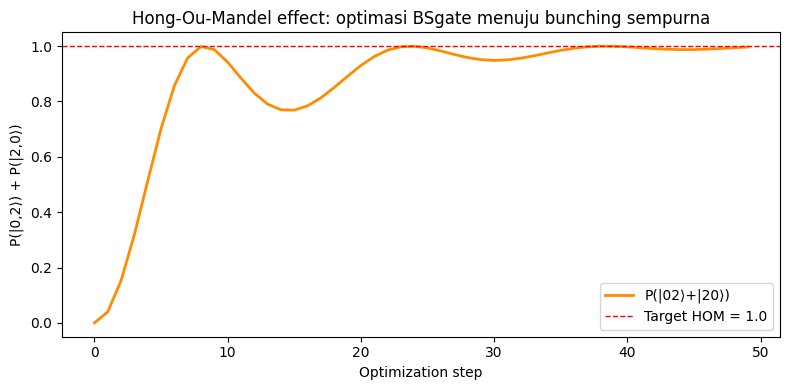

In [3]:
import strawberryfields as sf
import tensorflow as tf
import numpy as np

# ── Setup ────────────────────────────────────────────────────────────────────

# BUG FIX Script 5.6 di paper:
# Paper menggunakan prepare_fock_state sebagai backend_options — ini SALAH.
# backend_options tidak mendukung parameter itu. Inisialisasi state foton
# harus dilakukan di dalam circuit context dengan sf.ops.Fock().

eng = sf.Engine(
    backend="tf",
    backend_options={"cutoff_dim": 7}
    # cutoff=7 cukup untuk menangkap state |0,2⟩ dan |2,0⟩.
    # Tidak perlu prepare_fock_state di sini (itu bug paper).
)

circuit = sf.Program(2)   # 2 qumode untuk dua foton yang masuk dari sisi berbeda.

# Parameter BSgate yang akan dioptimasi.
tf_theta = tf.Variable(tf.random.normal(shape=[], stddev=0.001))
          # θ: sudut transmittivity beamsplitter, inisialisasi dekat nol.
tf_phi   = tf.Variable(tf.random.normal(shape=[], stddev=0.001))
          # ϕ: sudut fase beamsplitter.

theta_sym, phi_sym = circuit.params("theta", "phi")

with circuit.context as q:
    sf.ops.Fock(1) | q[0]   # Persiapkan 1 foton di mode q[0].
                              # Fock(n)|0⟩ = |n⟩ — state dengan tepat n foton.
    sf.ops.Fock(1) | q[1]   # Persiapkan 1 foton di mode q[1].
                              # State awal total: |1,1⟩ — satu foton di tiap port.

    sf.ops.BSgate(theta_sym, phi_sym) | (q[0], q[1])
    # BSgate(θ, ϕ): beamsplitter parametrik.
    # Efek pada Fock states: bergantung pada θ (transmittivity) dan ϕ (fase).
    # Untuk |1,1⟩: output adalah superposisi |0,2⟩ dan |2,0⟩ ketika θ=π/4.
    # Ini adalah Hong-Ou-Mandel effect: foton identik selalu keluar bersama!

# ── Loop optimasi ─────────────────────────────────────────────────────────────

opt      = tf.keras.optimizers.Adam(learning_rate=0.1)
steps    = 50      # 50 langkah cukup karena landskap loss sangat smooth di sini.
best_prob = 0
prob_history = []

for step in range(steps):

    if eng.run_progs:
        eng.reset()   # Reset wajib sebelum run ulang (sama seperti Script 5.5).

    with tf.GradientTape() as tape:
        results = eng.run(circuit, args={"theta": tf_theta, "phi": tf_phi})

        # Probabilitas mendapatkan |0,2⟩ atau |2,0⟩ (keduanya adalah HOM output).
        prob_02 = results.state.fock_prob([0, 2])
        prob_20 = results.state.fock_prob([2, 0])
        prob    = prob_02 + prob_20
        # Target: prob → 1.0, artinya P(|1,1⟩) = 0 (HOM bunching sempurna).

        loss = 1 - tf.sqrt(prob)
        # Loss function sama seperti displacement gate: minimize 1-√prob.
        # Mengoptimasi √prob lebih stabil daripada prob langsung.

    gradients = tape.gradient(loss, [tf_theta, tf_phi])
    opt.apply_gradients(zip(gradients, [tf_theta, tf_phi]))

    prob_val = float(prob)
    prob_history.append(prob_val)

    if prob_val > best_prob:
        best_prob  = prob_val
        best_theta = float(tf_theta)
        best_phi   = float(tf_phi)
        best_state = results.state

    if step % 10 == 0:
        print(f"Step {step:2d}: P(|02⟩+|20⟩) = {prob_val:.4f}, θ = {float(tf_theta):.4f}")

print(f"\nHasil HOM optimization:")
print(f"  P(|02⟩+|20⟩) optimal: {best_prob:.4f}  (target: 1.0)")
print(f"  θ_optimal: {best_theta:.4f}  (ekspektasi: ±π/4 ≈ ±0.785)")
print(f"  ϕ_optimal: {best_phi:.4f}  (ϕ tidak penting karena HOM berlaku untuk semua ϕ)")

# Verifikasi HOM effect secara analitik untuk BSgate 50-50 (θ=π/4).
print(f"\nVerifikasi analitik (θ=π/4):")
print(f"  P(|0,2⟩) + P(|2,0⟩) harus = 1.0 karena HOM bunching sempurna")
print(f"  P(|1,1⟩) harus = 0.0 karena interferensi destruktif boson identik")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(prob_history, lw=2, color='darkorange', label='P(|02⟩+|20⟩)')
plt.axhline(1.0, color='red', ls='--', lw=1, label='Target HOM = 1.0')
plt.xlabel('Optimization step')
plt.ylabel('P(|0,2⟩) + P(|2,0⟩)')
plt.title('Hong-Ou-Mandel effect: optimasi BSgate menuju bunching sempurna')
plt.legend()
plt.tight_layout()
plt.show()

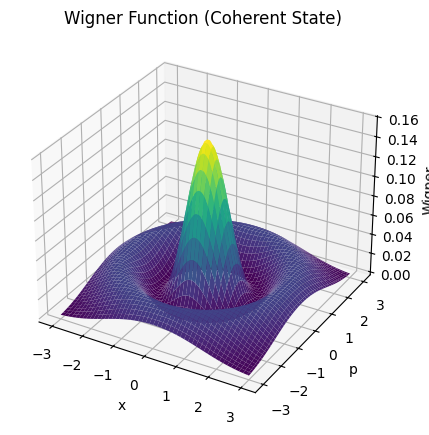

In [5]:
# ── Plot Wigner function (ini yang bikin seperti gambar pertama) ────────────

x = np.linspace(-3, 3, 100)
p = np.linspace(-3, 3, 100)

state = results.state  # ambil state terakhir

W = state.wigner(0, x, p)  # mode ke-0

X, P = np.meshgrid(x, p)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, P, W, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('p')
ax.set_zlabel('Wigner')

ax.set_title('Wigner Function (Coherent State)')
plt.show()